Dataset Introduction: Melbourne Housing Snapshot
This project uses the Melbourne Housing Snapshot dataset from Kaggle (originally scraped from Domain.com.au by Tony Pino), which contains real estate sale records from the Melbourne, Australia housing market. The dataset captures property listings, prices, and sale details, making it well-suited for a regression task predicting house prices, along with meaningful data cleaning practice since it contains real missing values.

Dataset link: https://www.kaggle.com/datasets/dansbecker/melbourne-housing-snapshot

# -----------------------------
# 1. IMPORT AND LOAD DATASET
# -----------------------------

In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [9]:
df= pd.read_csv("melb_data.csv")
df

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra,-37.79960,144.99840,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.80790,144.99340,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.80930,144.99440,Northern Metropolitan,4019.0
3,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,4/03/2017,2.5,3067.0,...,2.0,1.0,94.0,NaN,NaN,Yarra,-37.79690,144.99690,Northern Metropolitan,4019.0
4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,4/06/2016,2.5,3067.0,...,1.0,2.0,120.0,142.0,2014.0,Yarra,-37.80720,144.99410,Northern Metropolitan,4019.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13575,Wheelers Hill,12 Strada Cr,4,h,1245000.0,S,Barry,26/08/2017,16.7,3150.0,...,2.0,2.0,652.0,NaN,1981.0,NaN,-37.90562,145.16761,South-Eastern Metropolitan,7392.0
13576,Williamstown,77 Merrett Dr,3,h,1031000.0,SP,Williams,26/08/2017,6.8,3016.0,...,2.0,2.0,333.0,133.0,1995.0,NaN,-37.85927,144.87904,Western Metropolitan,6380.0
13577,Williamstown,83 Power St,3,h,1170000.0,S,Raine,26/08/2017,6.8,3016.0,...,2.0,4.0,436.0,NaN,1997.0,NaN,-37.85274,144.88738,Western Metropolitan,6380.0
13578,Williamstown,96 Verdon St,4,h,2500000.0,PI,Sweeney,26/08/2017,6.8,3016.0,...,1.0,5.0,866.0,157.0,1920.0,NaN,-37.85908,144.89299,Western Metropolitan,6380.0


# -----------------------------
# 2. Understand the Dataset
# -----------------------------

In [10]:
df.describe() #Summary Statistics

,Rooms,Price,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude,Propertycount
count,13580.000000,1.358000e+04,13580.000000,13580.000000,13580.000000,13580.000000,13518.000000,13580.000000,7130.000000,8205.000000,13580.000000,13580.000000,13580.000000
mean,2.937997,1.075684e+06,10.137776,3105.301915,2.914728,1.534242,1.610075,558.416127,151.967650,1964.684217,-37.809203,144.995216,7454.417378
std,0.955748,6.393107e+05,5.868725,90.676964,0.965921,0.691712,0.962634,3990.669241,541.014538,37.273762,0.079260,0.103916,4378.581772
min,1.000000,8.500000e+04,0.000000,3000.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1196.000000,-38.182550,144.431810,249.000000
25%,2.000000,6.500000e+05,6.100000,3044.000000,2.000000,1.000000,1.000000,177.000000,93.000000,1940.000000,-37.856822,144.929600,4380.000000
50%,3.000000,9.030000e+05,9.200000,3084.000000,3.000000,1.000000,2.000000,440.000000,126.000000,1970.000000,-37.802355,145.000100,6555.000000
75%,3.000000,1.330000e+06,13.000000,3148.000000,3.000000,2.000000,2.000000,651.000000,174.000000,1999.000000,-37.756400,145.058305,10331.000000
max,10.000000,9.000000e+06,48.100000,3977.000000,20.000000,8.000000,10.000000,433014.000000,44515.000000,2018.000000,-37.408530,145.526350,21650.000000


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13580 entries, 0 to 13579
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         13580 non-null  object 
 1   Address        13580 non-null  object 
 2   Rooms          13580 non-null  int64  
 3   Type           13580 non-null  object 
 4   Price          13580 non-null  float64
 5   Method         13580 non-null  object 
 6   SellerG        13580 non-null  object 
 7   Date           13580 non-null  object 
 8   Distance       13580 non-null  float64
 9   Postcode       13580 non-null  float64
 10  Bedroom2       13580 non-null  float64
 11  Bathroom       13580 non-null  float64
 12  Car            13518 non-null  float64
 13  Landsize       13580 non-null  float64
 14  BuildingArea   7130 non-null   float64
 15  YearBuilt      8205 non-null   float64
 16  CouncilArea    12211 non-null  object 
 17  Lattitude      13580 non-null  float64
 18  Longti

Insights:   BuildingArea    6450
            YearBuilt       5375
            CouncilArea     1369
            Car               62

This 4 columns has missing values and according to missing values we will used dropna or fillna method.

In [12]:
df.shape

(13580, 21)

In [13]:
df.dtypes

Suburb            object
Address           object
Rooms              int64
Type              object
Price            float64
Method            object
SellerG           object
Date              object
Distance         float64
Postcode         float64
Bedroom2         float64
Bathroom         float64
Car              float64
Landsize         float64
BuildingArea     float64
YearBuilt        float64
CouncilArea       object
Lattitude        float64
Longtitude       float64
Regionname        object
Propertycount    float64
dtype: object

In [14]:
df.columns

Index(['Suburb', 'Address', 'Rooms', 'Type', 'Price', 'Method', 'SellerG',
       'Date', 'Distance', 'Postcode', 'Bedroom2', 'Bathroom', 'Car',
       'Landsize', 'BuildingArea', 'YearBuilt', 'CouncilArea', 'Lattitude',
       'Longtitude', 'Regionname', 'Propertycount'],
      dtype='object')

Insights: BuildingArea, YearBuilt, CouncilArea, Car have missing tow.         

# -----------------------------
# 3. DATA CLEANING
# -----------------------------

In [15]:
df.sample(2)

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
8202,Ormond,3/10 Ormond Rd,1,u,311500.0,PI,Ray,29/04/2017,11.8,3204.0,...,1.0,1.0,0.0,NaN,NaN,Glen Eira,-37.9032,145.0455,Southern Metropolitan,3578.0
4085,Moonee Ponds,30 Tennyson St,3,h,1505000.0,S,Jellis,12/11/2016,6.9,3039.0,...,2.0,2.0,249.0,168.0,2007.0,Moonee Valley,-37.7609,144.9296,Western Metropolitan,6232.0


In [16]:
# Check missing values

missing = df.isna().sum().sort_values(ascending=False)
missing[missing>0]

BuildingArea    6450
YearBuilt       5375
CouncilArea     1369
Car               62
dtype: int64

In [17]:
df.shape

(13580, 21)

In [18]:
df = df.dropna(subset= ['Car'])

In [19]:
df.shape

(13518, 21)

In [20]:
df['CouncilArea'] = df['CouncilArea'].fillna(df['CouncilArea'].mode()[0])
df['YearBuilt'] = df['YearBuilt'].fillna(df['YearBuilt'].median())
df['BuildingArea'] = df['BuildingArea'].fillna(df['BuildingArea'].median())

# check
print(df[['Car', 'CouncilArea', 'YearBuilt', 'BuildingArea']].isnull().sum())

Car             0
CouncilArea     0
YearBuilt       0
BuildingArea    0
dtype: int64


# -----------------------------
# 4. DATA FORMATTING (formatting to incosistent data types)
# -----------------------------

In [21]:
df['Date'] = pd.to_datetime(df['Date'], format = '%d/%m/%Y')
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13518 entries, 0 to 13579
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Suburb         13518 non-null  object        
 1   Address        13518 non-null  object        
 2   Rooms          13518 non-null  int64         
 3   Type           13518 non-null  object        
 4   Price          13518 non-null  float64       
 5   Method         13518 non-null  object        
 6   SellerG        13518 non-null  object        
 7   Date           13518 non-null  datetime64[ns]
 8   Distance       13518 non-null  float64       
 9   Postcode       13518 non-null  float64       
 10  Bedroom2       13518 non-null  float64       
 11  Bathroom       13518 non-null  float64       
 12  Car            13518 non-null  float64       
 13  Landsize       13518 non-null  float64       
 14  BuildingArea   13518 non-null  float64       
 15  YearBuilt      13518 non

# -----------------------------
# 5. OUTLIER DETECTION AND REMOVING USING IQR METHOD
# -----------------------------

In [22]:
# Detect outliers in Price

Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)
IQ3 = Q3-Q1

lower =     Q1 - 1.5 * IQ3
upper = Q1 + 1.5 * IQ3

outliers = df[(df['Price'] < lower) | (df['Price'] > upper)]

print("Number of Outliers:", len(outliers))

Number of Outliers: 1863


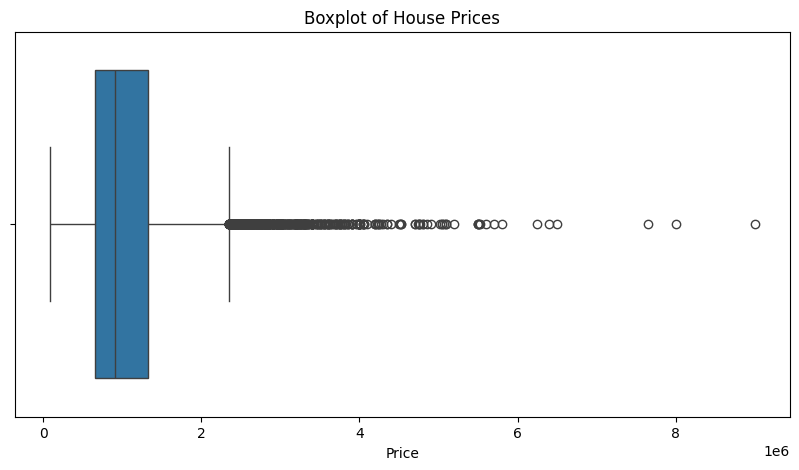

In [23]:
plt.figure(figsize=(10,5))
sns.boxplot(x=df['Price'])
plt.title("Boxplot of House Prices")
plt.show()


In [24]:
# # Remove outliers
# df = df[(df['Price'] >= lower) & (df['Price'] <= upper)]

# print("Shape after removing outliers:", df.shape)

# # Boxplot after removing outliers
# plt.figure(figsize=(10,5))
# sns.boxplot(x=df['Price'])
# plt.title("Boxplot After Removing Outliers")
# plt.show()

# -----------------------------
# 6. EDA AND DATA VISULIZTION USING SEABORN AND MATPLOTLIB
# -----------------------------

# -----------------------------
# i. Univariate Analysis
# -----------------------------


# -----------------------------
# i.i Univariate Analysis - Numerical Variables
# -----------------------------

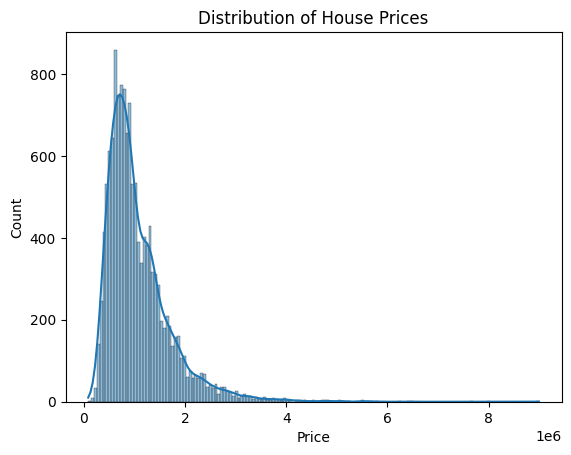

In [25]:
sns.histplot(data=df,
             x='Price', kde=True)
plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

Insights: 
The distribution of house prices is positively (right) skewed, with most properties concentrated at lower price ranges.


# -----------------------------
# i.ii Univariate Analysis - Catrgorical Variables
# -----------------------------

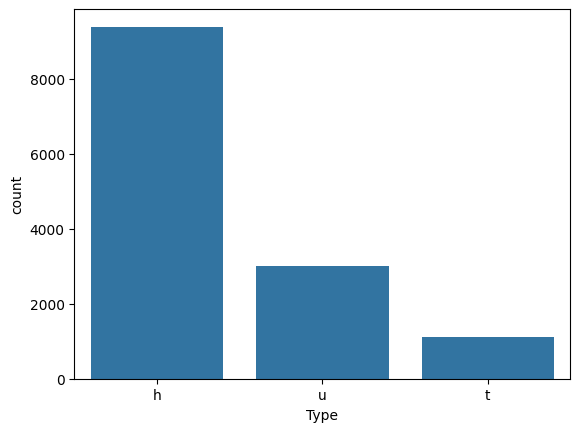

In [26]:
sns.countplot(x="Type", data=df)
plt.show()

# -----------------------------
# ii. Bivariate Analysis
# -----------------------------

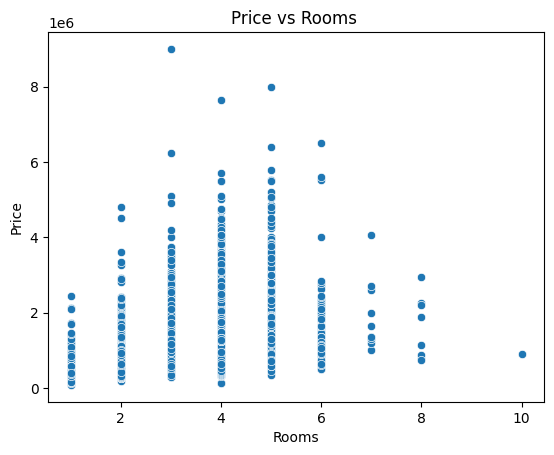

In [27]:
# Price vs Rooms 


sns.scatterplot(x="Rooms", y="Price", data=df)
plt.title("Price vs Rooms ")
plt.show()

In [28]:
df.head(2)

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,2016-12-03,2.5,3067.0,...,1.0,1.0,202.0,126.0,1970.0,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,2016-02-04,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0


Clubing features together - Location

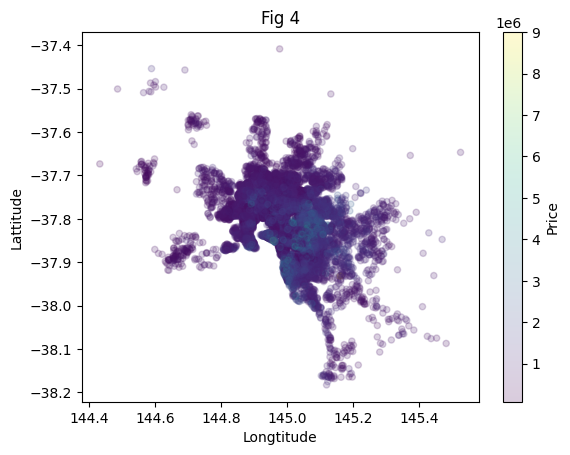

In [29]:
#most expensive to the least expensive areas
df.plot(kind="scatter", x="Longtitude", y="Lattitude", c = "Price", alpha=0.2, colorbar=True, sharex=False, cmap=plt.get_cmap("viridis"))
plt.title('Fig 4')
plt.show()
#plt.savefig('map1.png')

# -----------------------------
# ii. Multivariate Analysis
# -----------------------------

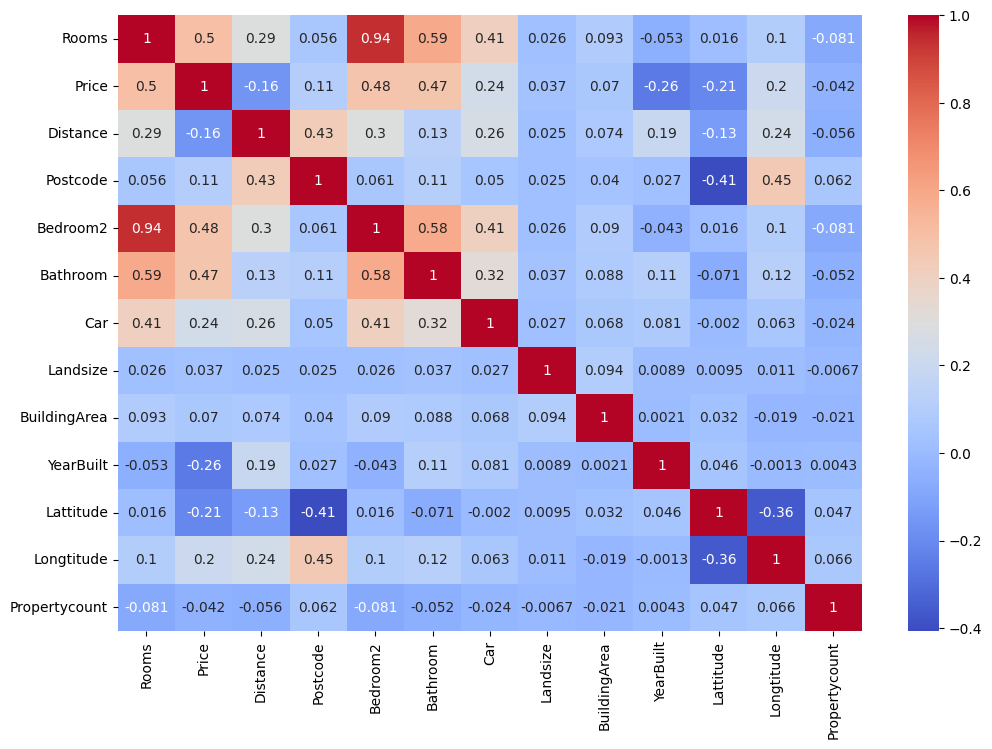

In [30]:
corr = df.corr(numeric_only=True)


plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

INSIGHTS:

1. Rooms and Bedroom2 (0.94) are almost duplicate features, and both correlate most strongly with Price (0.5 and 0.48), showing that room count is the single biggest driver of house price.

2. Bathroom (0.47) and Car spots (0.24) also push price up, meaning bigger, more equipped houses cost more.

3. YearBuilt (-0.26) and Latitude (-0.21) have a weak negative link with Price, meaning older properties and homes further north tend to be slightly cheaper.

4. Landsize (0.037) and BuildingArea (0.07) barely correlate with Price, so plot/building size alone doesn't explain cost much — location and rooms matter more.
Postcode and Longitude (0.45) are strongly linked (expected, since postcode encodes location), so they carry overlapping location information.

In [31]:
#Top Correlation with Price
corr["Price"].sort_values(ascending=False) 

Price            1.000000
Rooms            0.497656
Bedroom2         0.476846
Bathroom         0.467720
Car              0.238979
Longtitude       0.204093
Postcode         0.107371
BuildingArea     0.069875
Landsize         0.037482
Propertycount   -0.041673
Distance        -0.161081
Lattitude       -0.212444
YearBuilt       -0.258081
Name: Price, dtype: float64

Correlation with Price

Rooms (0.498) has the strongest positive correlation with Price, indicating that houses with more rooms generally have higher prices.

Bedroom2 (0.477) and Bathroom (0.468) also show moderate positive correlations with price.

Car (0.239) and Longitude (0.204) have weak positive relationships with house prices.

Distance (-0.161) has a weak negative correlation, suggesting that properties farther from the city center tend to be less expensive.

YearBuilt (-0.258) shows a weak negative correlation with price in this dataset.

Landsize (0.037) and BuildingArea (0.070) have very weak correlations with price, indicating little linear relationship.

Overall, Rooms, Bedroom2, and Bathroom are the most influential numerical features associated with house prices based on correlation analysis.



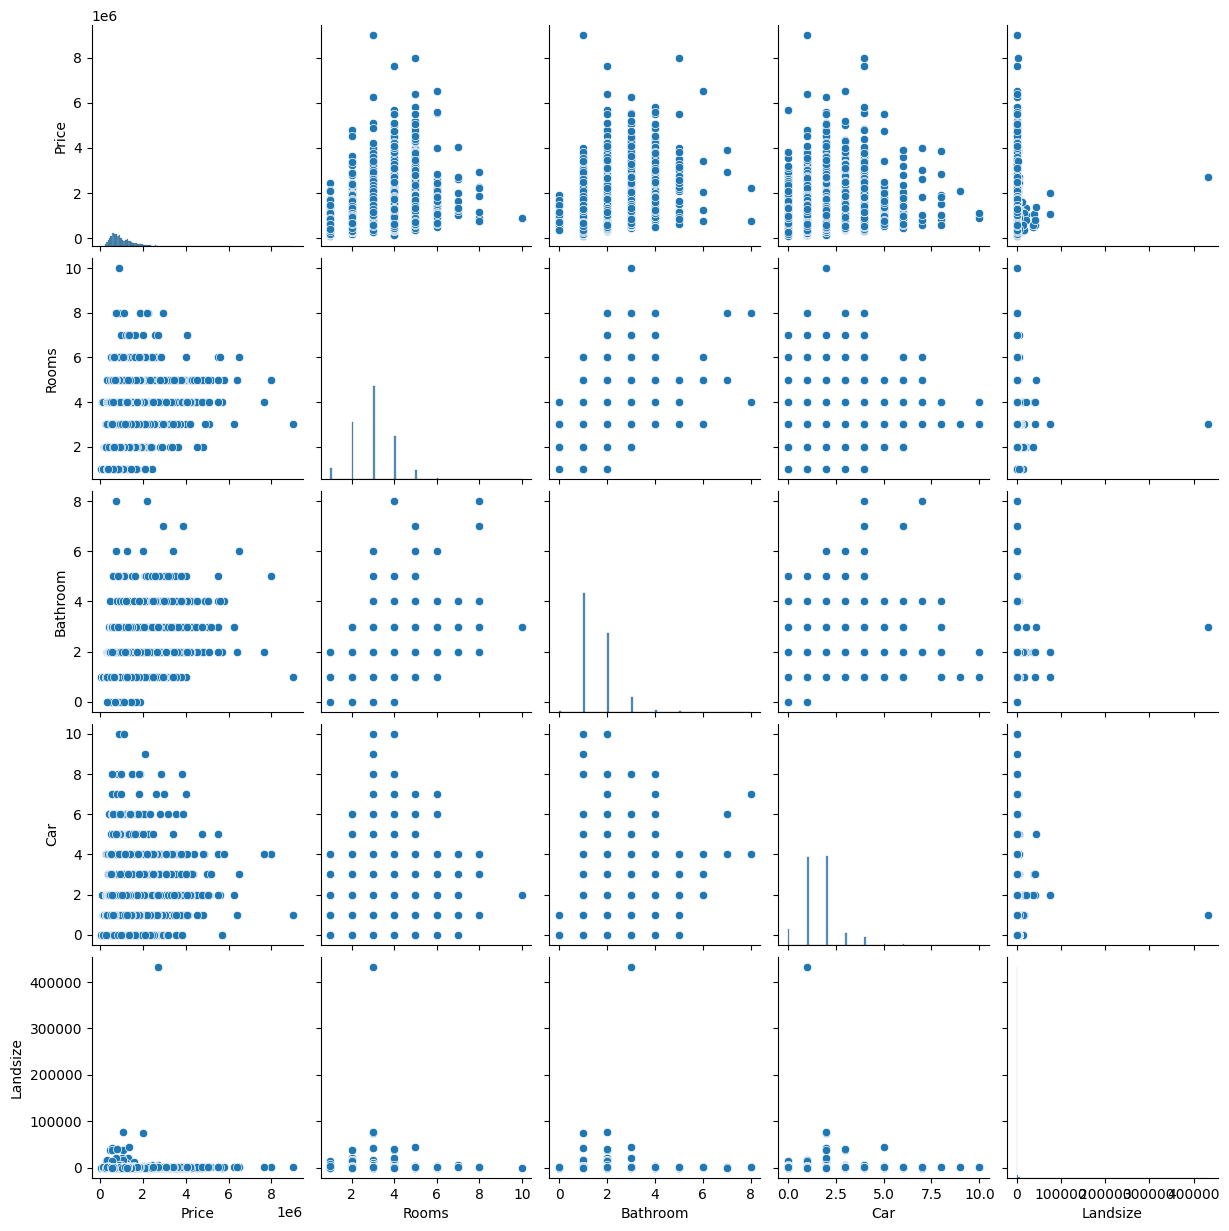

In [32]:
sns.pairplot(df[["Price","Rooms","Bathroom","Car","Landsize"]])
plt.show()

Final EDA Insights from above steps :



1. Dataset contains 13,580 properties.
2. Missing values were found in BuildingArea, YearBuilt, Car, etc.
3. Missing values were handled using median (numerical) and mode (categorical).
4. House prices are right-skewed.
5. Several high-price outliers exist.
6. Properties with more rooms and bathrooms generally have higher prices.
7. Landsize has a positive relationship with price, but includes extreme outliers.
8. Regionname and Type influence property prices.
9. Strong positive correlations exist between Rooms, Bedroom2, Bathroom, Car, and Price.

In [33]:
# Do this BEFORE train_test_split (or at least before scaling)
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df['SaleYear'] = df['Date'].dt.year # Year - captures the overall market trend
df['SaleMonth'] = df['Date'].dt.month # Month - captures seasonality
df = df.drop(columns=['Date'])   

# -----------------------------
# 7. Feature Engineering for Machine Learning
# -----------------------------

In [34]:
# Separate features and target

X = df.drop(columns=["Price", "Address"])

# NOTE: I remove address because it has more than 8000 unique address which does not
#make sense while prediction house price as it would have more columns

y = df["Price"]

# One-hot encode categorical variables
X = pd.get_dummies(X, drop_first=True)

In [35]:
X.head(2)

,Rooms,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,...,CouncilArea_Wyndham,CouncilArea_Yarra,CouncilArea_Yarra Ranges,Regionname_Eastern Victoria,Regionname_Northern Metropolitan,Regionname_Northern Victoria,Regionname_South-Eastern Metropolitan,Regionname_Southern Metropolitan,Regionname_Western Metropolitan,Regionname_Western Victoria
0,2,2.5,3067.0,2.0,1.0,1.0,202.0,126.0,1970.0,-37.7996,...,False,True,False,False,True,False,False,False,False,False
1,2,2.5,3067.0,2.0,1.0,0.0,156.0,79.0,1900.0,-37.8079,...,False,True,False,False,True,False,False,False,False,False


In [36]:
y

0        1480000.0
1        1035000.0
2        1465000.0
3         850000.0
4        1600000.0
           ...    
13575    1245000.0
13576    1031000.0
13577    1170000.0
13578    2500000.0
13579    1285000.0
Name: Price, Length: 13518, dtype: float64

Train -TEST SPLIT

In [37]:
from sklearn.model_selection import train_test_split

In [38]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [39]:
print(X_train.shape, X_test.shape)

(10814, 639) (2704, 639)


In [40]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((10814, 639), (10814,), (2704, 639), (2704,))

In [41]:
from sklearn.preprocessing import StandardScaler

In [42]:
scaler = StandardScaler()
X_train_scale = scaler.fit_transform(X_train)
X_test_scale = scaler.transform(X_test)

Model Training + Hyperparameter Tuning

In [43]:
from sklearn.linear_model import LinearRegression, Ridge,Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [44]:
models = {

    "LinearRegression" : LinearRegression(),
    "Ridge" : Ridge(),
    "Lasso" : Lasso(),
    "ElasticNet" : ElasticNet(),
    "RandomForestRegressor" : RandomForestRegressor(n_jobs=-1, random_state=42,
                                                    n_estimators=100,),
    # "SVR" : SVR(max_iter=1000),
    "XGBRegressor": XGBRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
        # learning_rate=0.1,
        )

}

In [45]:
scale_required = {"SVR", "LinearRegression", "Ridge", "Lasso", "ElasticNet"}

'''     note: 
Why some models use scaled data and others don't?
Linear models (LinearRegression, Ridge, Lasso, ElasticNet), KNN, and SVR are sensitive to feature scale
because they rely on distances or coefficient magnitudes, so features with large ranges can dominate the 
result unless scaled. Tree-based models (DecisionTree, RandomForest, GradientBoosting, AdaBoost, XGBoost) 
split data using thresholds on each feature independently, so scale doesn't affect them at all.
'''

"     note: \nWhy some models use scaled data and others don't?\nLinear models (LinearRegression, Ridge, Lasso, ElasticNet), KNN, and SVR are sensitive to feature scale\nbecause they rely on distances or coefficient magnitudes, so features with large ranges can dominate the \nresult unless scaled. Tree-based models (DecisionTree, RandomForest, GradientBoosting, AdaBoost, XGBoost) \nsplit data using thresholds on each feature independently, so scale doesn't affect them at all.\n"

In [46]:
print(df.shape)
print(X_train.shape)

(13518, 22)
(10814, 639)


In [47]:
for col in df.columns:
    print(f"{col}: {df[col].nunique()}")

Suburb: 314
Address: 13318
Rooms: 9
Type: 3
Price: 2200
Method: 5
SellerG: 268
Distance: 202
Postcode: 198
Bedroom2: 12
Bathroom: 9
Car: 11
Landsize: 1444
BuildingArea: 602
YearBuilt: 144
CouncilArea: 33
Lattitude: 6458
Longtitude: 7006
Regionname: 8
Propertycount: 311
SaleYear: 2
SaleMonth: 12


In [48]:
result_list = []   
 # used here because it converts to a dataframe easily  # and lets us compare models

 
for model_name, model in models.items():

    print(f"\nTraining {model_name}...")

    if model_name in scale_required:
        X_tr, X_te = X_train_scale, X_test_scale
    else:
        X_tr, X_te = X_train, X_test

    model.fit(X_tr, y_train) # Train the model

    print(f"{model_name} finished.")
    
    # make predictions:

    y_train_pred = model.predict(X_tr)
    y_test_pred = model.predict(X_te)   


    # Training set performance
    model_train_mae = mean_absolute_error(y_train, y_train_pred)
    model_train_mse = mean_squared_error(y_train, y_train_pred)
    model_train_rmse = np.sqrt(model_train_mse)
    model_train_r2 = r2_score(y_train, y_train_pred)

    # Test set performance
    model_test_mae = mean_absolute_error(y_test, y_test_pred)
    model_test_mse = mean_squared_error(y_test, y_test_pred)
    model_test_rmse = np.sqrt(model_test_mse)
    model_test_r2 = r2_score(y_test, y_test_pred)

    # Store results in dictionary
    result_list.append({
        'Model': model_name,
        'Train_MAE': model_train_mae,
        'Train_RMSE': model_train_rmse,
        'Train_R2': model_train_r2,
        'Test_MAE': model_test_mae,
        'Test_RMSE': model_test_rmse,
        'Test_R2': model_test_r2
    })

    # Print results
    print(f"Model: {model_name}")
    print("Training set performance")
    print("MAE: {:.4f}".format(model_train_mae))
    print("RMSE: {:.4f}".format(model_train_rmse))
    print("R2 Score: {:.4f}".format(model_train_r2))
    print("\nTest set performance")
    print("MAE: {:.4f}".format(model_test_mae))
    print("RMSE: {:.4f}".format(model_test_rmse))
    print("R2 Score: {:.4f}\n".format(model_test_r2))
    print("------------------------------------------------")

# ============== CREATE FINAL DATAFRAME ==============

df_results = pd.DataFrame(result_list)                                                 


Training LinearRegression...
LinearRegression finished.
Model: LinearRegression
Training set performance
MAE: 221291.1050
RMSE: 342832.4781
R2 Score: 0.7126

Test set performance
MAE: 236970.4981
RMSE: 456412.5401
R2 Score: 0.4934

------------------------------------------------

Training Ridge...
Ridge finished.
Model: Ridge
Training set performance
MAE: 221280.0759
RMSE: 342832.8578
R2 Score: 0.7126

Test set performance
MAE: 236924.1739
RMSE: 456331.9023
R2 Score: 0.4936

------------------------------------------------

Training Lasso...
Lasso finished.
Model: Lasso
Training set performance
MAE: 221289.7000
RMSE: 342832.9115
R2 Score: 0.7126

Test set performance
MAE: 237995.9375
RMSE: 461898.4793
R2 Score: 0.4811

------------------------------------------------

Training ElasticNet...
ElasticNet finished.
Model: ElasticNet
Training set performance
MAE: 227816.6720
RMSE: 364321.1345
R2 Score: 0.6754

Test set performance
MAE: 238272.4476
RMSE: 481071.1499
R2 Score: 0.4372

-----

In [49]:
df_results

,Model,Train_MAE,Train_RMSE,Train_R2,Test_MAE,Test_RMSE,Test_R2
0,LinearRegression,221291.105011,342832.478113,0.712562,236970.498054,456412.540092,0.493380
1,Ridge,221280.075909,342832.857801,0.712562,236924.173890,456331.902295,0.493559
2,Lasso,221289.700018,342832.911523,0.712562,237995.937468,461898.479341,0.481128
3,ElasticNet,227816.672041,364321.134464,0.675400,238272.447624,481071.149925,0.437159
4,RandomForestRegressor,60531.995677,107520.067576,0.971728,160971.746816,274135.349803,0.817233
5,XGBRegressor,105404.954940,152983.750752,0.942764,163124.438338,265694.459951,0.828315


In [50]:
df_results[['Model','Train_R2','Test_R2']].sort_values('Test_R2', ascending=False)

,Model,Train_R2,Test_R2
5,XGBRegressor,0.942764,0.828315
4,RandomForestRegressor,0.971728,0.817233
1,Ridge,0.712562,0.493559
0,LinearRegression,0.712562,0.493380
2,Lasso,0.712562,0.481128
3,ElasticNet,0.675400,0.437159


In [51]:
df_results[np.logical_and(df_results['Train_R2']>=0.5, df_results['Test_R2']>=0.5)][['Model','Train_R2','Test_R2']]

,Model,Train_R2,Test_R2
4,RandomForestRegressor,0.971728,0.817233
5,XGBRegressor,0.942764,0.828315


In [52]:
best_model_name = df_results.sort_values('Test_R2', ascending=False).iloc[0]['Model']
print(f"Best performing model on test set: {best_model_name}")

Best performing model on test set: XGBRegressor


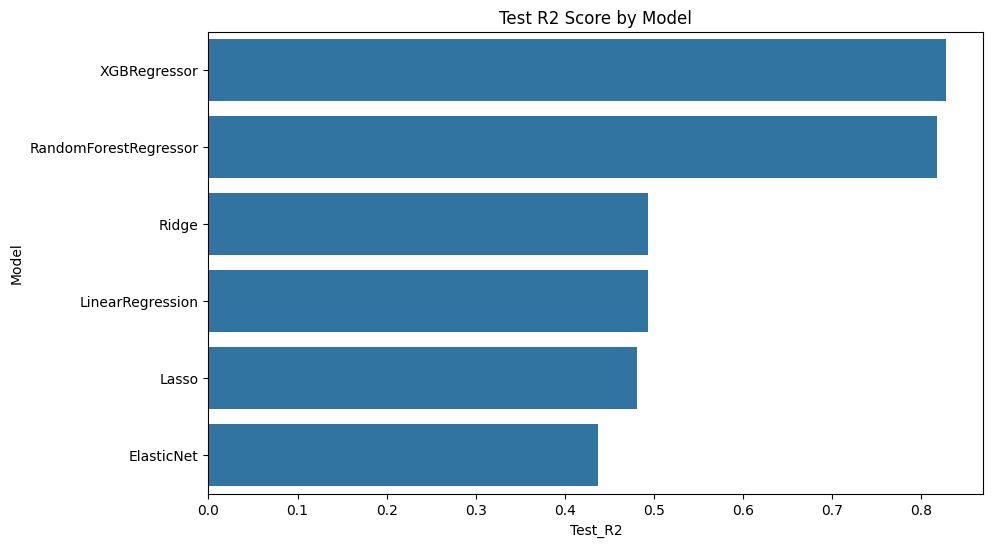

In [53]:
plt.figure(figsize=(10,6))
sns.barplot(data=df_results.sort_values('Test_R2', ascending=False), x='Test_R2', y='Model')
plt.title('Test R2 Score by Model')
plt.show()

In [54]:
# See which models performed best on test data
df_results_sorted = df_results.sort_values('Test_R2', ascending=False).reset_index(drop=True)
df_results_sorted[['Model', 'Test_MAE', 'Test_RMSE', 'Test_R2', 'Train_R2']]


,Model,Test_MAE,Test_RMSE,Test_R2,Train_R2
0,XGBRegressor,163124.438338,265694.459951,0.828315,0.942764
1,RandomForestRegressor,160971.746816,274135.349803,0.817233,0.971728
2,Ridge,236924.173890,456331.902295,0.493559,0.712562
3,LinearRegression,236970.498054,456412.540092,0.493380,0.712562
4,Lasso,237995.937468,461898.479341,0.481128,0.712562
5,ElasticNet,238272.447624,481071.149925,0.437159,0.675400


In [55]:
# Quick insights before tuning
best_model = df_results_sorted.loc[0, 'Model']
best_r2 = df_results_sorted.loc[0, 'Test_R2']
gap = df_results_sorted.loc[0, 'Train_R2'] - df_results_sorted.loc[0, 'Test_R2']

print(f"Best model so far: {best_model} (Test R2 = {best_r2:.4f})")
print(f"Train R2 - Test R2 gap = {gap:.4f}  (bigger gap means more overfitting)")

top = df_results_sorted['Model'].head(2).tolist()
print(f"\nWe will run GridSearchCV on these top 2 models: {top}")


Best model so far: XGBRegressor (Test R2 = 0.8283)
Train R2 - Test R2 gap = 0.1144  (bigger gap means more overfitting)

We will run GridSearchCV on these top 2 models: ['XGBRegressor', 'RandomForestRegressor']


## Hyperparameter Tuning with GridSearchCV and Model Saving (Pickle)

In [56]:
from sklearn.model_selection import GridSearchCV

# Parameter grids for models that benefit meaningfully from tuning.
# NOTE: Plain LinearRegression has no hyperparameters to tune, so it is skipped automatically.
param_grids = {
    "RandomForestRegressor": {
        'n_estimators': [100, 200, 300],
        'max_depth': [10, 20, 30, None],
        'min_samples_split': [2, 5, 10],
        'max_features': ['sqrt', 'log2']
    },
    "XGBRegressor": {
        'n_estimators': [100, 200, 300],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.05, 0.1],
        'subsample': [0.8, 1.0]
    },
    "Ridge": {
        'alpha': [0.01, 0.1, 1, 10, 100]
    },
    "Lasso": {
        'alpha': [0.01, 0.1, 1, 10, 100]
    },
    "ElasticNet": {
        'alpha': [0.01, 0.1, 1, 10],
        'l1_ratio': [0.2, 0.5, 0.8]
    }
}


In [ ]:
tuned_results = []
tuned_models = {} # we will used pickle to save the models 

for model_name in top:
    if model_name not in param_grids:
        print(f"Skipping {model_name} - no hyperparameter grid needed/defined for this model.") 
        # plain Linear Regression skip and tune other models
        continue

    print(f"\nTuning {model_name} with GridSearchCV...")

    base_model = models[model_name]
    grid = param_grids[model_name]

    X_tr, X_te = (X_train_scale, X_test_scale) if model_name in scale_required else (X_train, X_test)

    gs = GridSearchCV(
        estimator=base_model,
        param_grid=grid, # try every combination in grid
        cv=3, # using 3-fold cross-validation
        scoring='r2', # judging by R² score
        n_jobs=-1, # using all CPU corers njobs = -1 for speed
        verbose=1 # for printing progress
    )
    gs.fit(X_tr, y_train)

    best_est = gs.best_estimator_
    tuned_models[model_name] = best_est # save on tunnermodels after finding best estimator

    y_test_pred = best_est.predict(X_te)

    mae = mean_absolute_error(y_test, y_test_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    r2 = r2_score(y_test, y_test_pred)

    print(f"Best Params for {model_name}: {gs.best_params_}")
    print(f"Tuned {model_name} -> Test MAE: {mae:.4f} | Test RMSE: {rmse:.4f} | Test R2: {r2:.4f}")

    tuned_results.append({
        'Model': model_name,
        'Test_MAE': mae,
        'Test_RMSE': rmse,
        'Test_R2': r2
    })

df_tuned_results = pd.DataFrame(tuned_results)
df_tuned_results



Tuning XGBRegressor with GridSearchCV...
Fitting 3 folds for each of 54 candidates, totalling 162 fits
Best Params for XGBRegressor: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 300, 'subsample': 0.8}
Tuned XGBRegressor -> Test MAE: 153655.1206 | Test RMSE: 255278.0229 | Test R2: 0.8415

Tuning RandomForestRegressor with GridSearchCV...
Fitting 3 folds for each of 72 candidates, totalling 216 fits
Best Params for RandomForestRegressor: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 300}
Tuned RandomForestRegressor -> Test MAE: 172648.4611 | Test RMSE: 286725.6531 | Test R2: 0.8001


,Model,Test_MAE,Test_RMSE,Test_R2
0,XGBRegressor,153655.120620,255278.022914,0.841513
1,RandomForestRegressor,172648.461076,286725.653084,0.800060


In [62]:
# Compare performance before vs after tuning
comparison = df_results_sorted[df_results_sorted['Model'].isin(top)][
    ['Model', 'Test_MAE', 'Test_RMSE', 'Test_R2']
].merge(df_tuned_results, on='Model', suffixes=('_before_tuning', '_after_tuning'))

comparison


,Model,Test_MAE_before_tuning,Test_RMSE_before_tuning,Test_R2_before_tuning,Test_MAE_after_tuning,Test_RMSE_after_tuning,Test_R2_after_tuning
0,XGBRegressor,163124.438338,265694.459951,0.828315,153655.120620,255278.022914,0.841513
1,RandomForestRegressor,160971.746816,274135.349803,0.817233,172648.461076,286725.653084,0.800060


In [68]:
# Select the final best model after tuning
final_best_name = df_tuned_results.sort_values('Test_R2', ascending=False).iloc[0]['Model']
final_best_model = tuned_models[final_best_name]

print(f"Final selected model after hyperparameter tuning: {final_best_name}")
print(f"Test R2 after tuning: {df_tuned_results.set_index('Model').loc[final_best_name, 'Test_R2']:.4f}")



Final selected model after hyperparameter tuning: XGBRegressor
Test R2 after tuning: 0.8415


### Save the Final Model (Pickle)

In [69]:
import pickle

needs_scaling = final_best_name in scale_required

artifact = {
    'model': final_best_model,
    'scaler': scaler,
    'feature_columns': list(X.columns),
    'needs_scaling': needs_scaling,
    'model_name': final_best_name
}

with open('melbourne_house_price_model.pkl', 'wb') as f:
    pickle.dump(artifact, f)

print("Model saved as 'melbourne_house_price_model.pkl'")


Model saved as 'melbourne_house_price_model.pkl'


### Load the Saved Model and Predict on New Data

In [70]:
with open('melbourne_house_price_model.pkl', 'rb') as f:
    loaded = pickle.load(f)

loaded_model = loaded['model']
loaded_scaler = loaded['scaler']
feature_columns = loaded['feature_columns']
needs_scaling = loaded['needs_scaling']

print(f"Loaded model: {loaded['model_name']}")


Loaded model: XGBRegressor


In [66]:
def predict_price(input_dict):
    """
    Predict house price for a new property.
    input_dict: a dictionary with the SAME raw column names used before one-hot encoding
                (i.e. same columns as df, excluding 'Price' and 'Address').
    Example keys: Suburb, Rooms, Type, Method, SellerG, Distance, Postcode, Bedroom2,
                  Bathroom, Car, Landsize, BuildingArea, YearBuilt, CouncilArea,
                  Lattitude, Longtitude, Regionname, Propertycount, SaleYear, SaleMonth
    """
    row = pd.DataFrame([input_dict])

    # One-hot encode the same way training data was encoded
    row_encoded = pd.get_dummies(row, drop_first=True)

    # Align columns with the training feature set (missing dummy columns filled with 0)
    row_encoded = row_encoded.reindex(columns=feature_columns, fill_value=0)

    # Scale if the loaded model needs scaled input
    row_final = loaded_scaler.transform(row_encoded) if needs_scaling else row_encoded

    predicted_price = loaded_model.predict(row_final)[0]
    return predicted_price


In [71]:
# Example new property - replace values with the actual details you want to predict
new_property = {
    'Suburb': 'Richmond',
    'Rooms': 3,
    'Type': 'h',
    'Method': 'S',
    'SellerG': 'Nelson',
    'Distance': 5.2,
    'Postcode': 3121,
    'Bedroom2': 3,
    'Bathroom': 2,
    'Car': 1,
    'Landsize': 450,
    'BuildingArea': 150,
    'YearBuilt': 2005,
    'CouncilArea': 'Yarra',
    'Lattitude': -37.80,
    'Longtitude': 144.99,
    'Regionname': 'Northern Metropolitan',
    'Propertycount': 4000,
    'SaleYear': 2017,
    'SaleMonth': 6
}

predicted_price = predict_price(new_property)
print(f"Predicted House Price: ${predicted_price:,.2f}")


Predicted House Price: $1,210,537.38
